# RAG

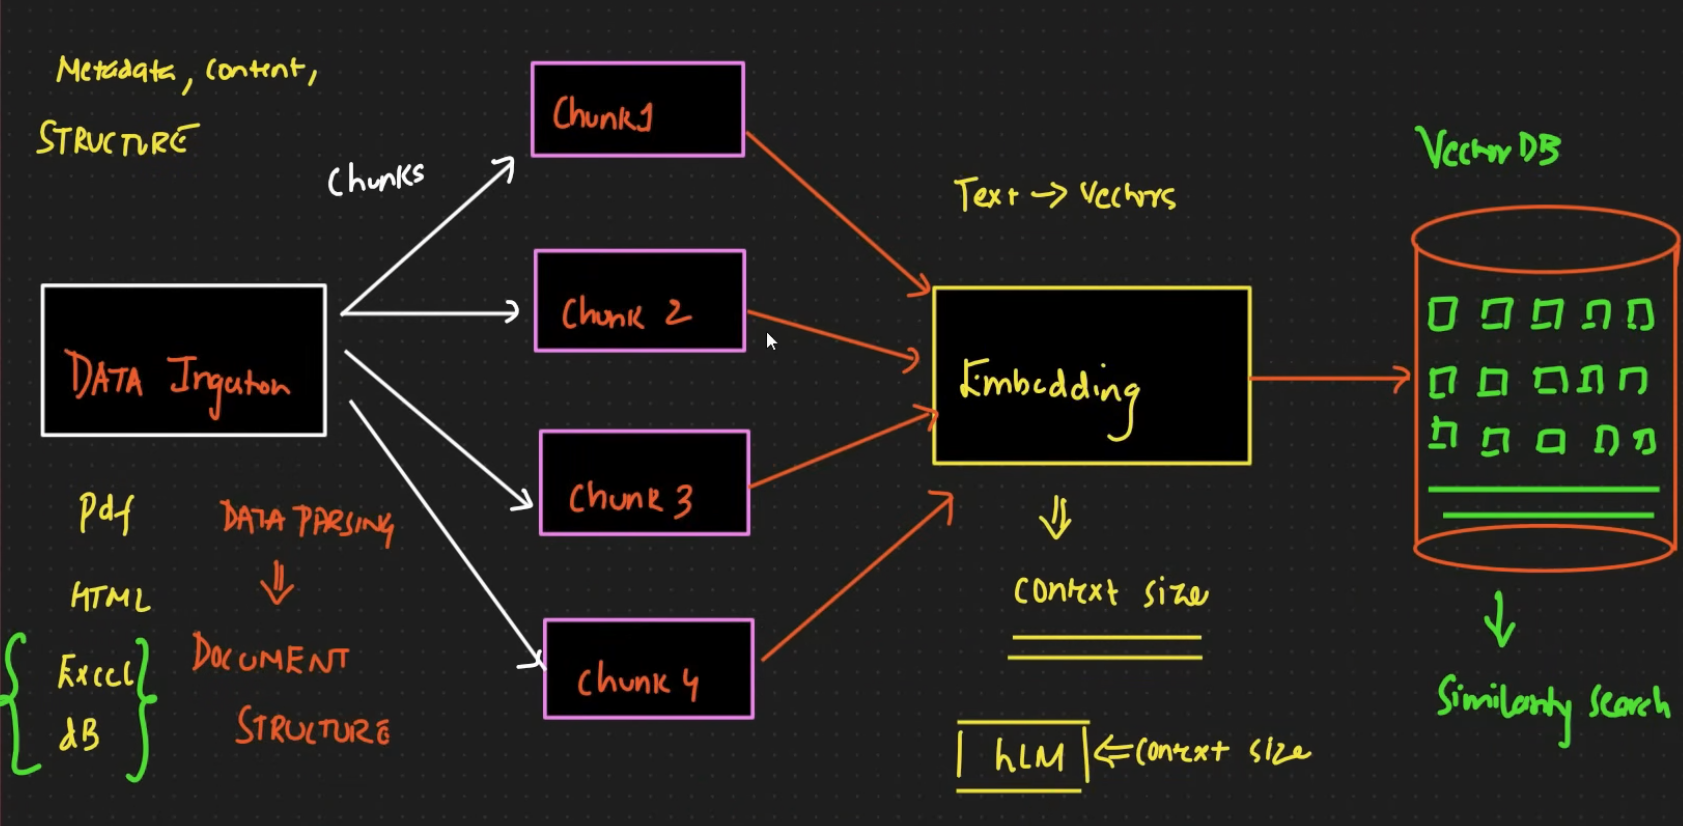

## Data Ingestion

### Document Datastructure

In [13]:
### Document Structure

from langchain_core.documents import Document

In [14]:
doc = Document(
    page_content="this is the main text content I am using to create RAG",
    metadata={
        "source":"example.txt",
        "page": 1,
        "author": "Vaishali",
        "date_created": "2026-07-17"
    } # improve search query retrieval; once storing everything in vectorDB; When doing similarity search we need to apply filters that's why metadata is important
)

doc

Document(metadata={'source': 'example.txt', 'page': 1, 'author': 'Vaishali', 'date_created': '2026-07-17'}, page_content='this is the main text content I am using to create RAG')

In [15]:
### Create a simple txt file

import os
os.makedirs("data/text_files", exist_ok=True)

In [16]:
BASE_TEXT_DIR = "langgraph/4-RAG/data/text_files"
BASE_DIR = "langgraph/4-RAG/data"

In [17]:
## Writing the content in the text_file

sample_texts={
    f"{BASE_TEXT_DIR}/python_intro.txt":"""Python Programming Introduction

Python is a high-level, interpreted programming language known for its simplicity and readability.
Created by Guido van Rossum and first released in 1991, Python has become one of the most popular
programming languages in the world.

Key Features:
- Easy to learn and use
- Extensive standard library
- Cross-platform compatibility
- Strong community support

Python is widely used in web development, data science, artificial intelligence, and automation.""",
    
    f"{BASE_TEXT_DIR}/machine_learning.txt": """Machine Learning Basics

Machine learning is a subset of artificial intelligence that enables systems to learn and improve
from experience without being explicitly programmed. It focuses on developing computer programs
that can access data and use it to learn for themselves.

Types of Machine Learning:
1. Supervised Learning: Learning with labeled data
2. Unsupervised Learning: Finding patterns in unlabeled data
3. Reinforcement Learning: Learning through rewards and penalties

Applications include image recognition, speech processing, and recommendation systems
    
    
    """

}


for filepath,content in sample_texts.items():
    with open(filepath,'w',encoding="utf-8") as f:
        f.write(content)

print("✅ Sample text files created!")


✅ Sample text files created!


### TextLoader

In [19]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader(f"{BASE_TEXT_DIR}/python_intro.txt", encoding="utf-8")
document = loader.load()
print(document)

[Document(metadata={'source': 'langgraph/4-RAG/data/text_files/python_intro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular\nprogramming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive standard library\n- Cross-platform compatibility\n- Strong community support\n\nPython is widely used in web development, data science, artificial intelligence, and automation.')]


### Directory Loader

In [20]:
from langchain_community.document_loaders import DirectoryLoader

## Load all the files from directory
dir_loader = DirectoryLoader(
    BASE_TEXT_DIR,
    glob="**/*.txt",
    loader_cls=TextLoader, # * If you have more than 1 loader then you can make it as a List [TextLoader, PdfLoader, ExcelLoader]
    loader_kwargs={"encoding": "utf-8"},
    show_progress=False
)

documents = dir_loader.load()
documents

[Document(metadata={'source': 'langgraph/4-RAG/data/text_files/python_intro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular\nprogramming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive standard library\n- Cross-platform compatibility\n- Strong community support\n\nPython is widely used in web development, data science, artificial intelligence, and automation.'),
 Document(metadata={'source': 'langgraph/4-RAG/data/text_files/machine_learning.txt'}, page_content='Machine Learning Basics\n\nMachine learning is a subset of artificial intelligence that enables systems to learn and improve\nfrom experience without being explicitly programmed. It focuses on developing computer programs\nthat can access data and use it to learn for themselves.\n\nTypes of Machi

### Why PyMuPDF is better than PyPdf
| Use Case                     | Recommended Library |
| ---------------------------- | ------------------- |
| RAG / LLM document ingestion | ✅ PyMuPDF           |
| Semantic search              | ✅ PyMuPDF           |
| OCR preprocessing            | ✅ PyMuPDF           |
| Extract images               | ✅ PyMuPDF           |
| Highlight or annotate PDFs   | ✅ PyMuPDF           |
| Merge/split PDFs             | ✅ PyPDF             |
| Encrypt/decrypt PDFs         | ✅ PyPDF             |
| Rotate/reorder pages         | ✅ PyPDF             |


In [ ]:
# Pymupdf is better in terms of speed, textExtraction, Images, tables, OCRSupports, Annotations, RAG Ready, etc
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
dir_loader = DirectoryLoader(
    f"{BASE_DIR}/pdf",
    glob="**/*.pdf",
    loader_cls=PyMuPDFLoader, # * If you have more than 1 loader then you can make it as a List [TextLoader, PdfLoader, ExcelLoader]
    show_progress=False
)

pdf_documents = dir_loader.load()
pdf_documents

[Document(metadata={'producer': '', 'creator': 'Microsoft Word', 'creationdate': '2026-03-25T02:27:45-07:00', 'source': 'langgraph/4-RAG/data/pdf/Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf', 'file_path': 'langgraph/4-RAG/data/pdf/Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf', 'total_pages': 10, 'format': 'PDF 1.7', 'title': '', 'author': 'Md Azlaan Barkat', 'subject': '', 'keywords': '', 'moddate': '2026-03-25T02:27:45-07:00', 'trapped': '', 'modDate': "D:20260325022745-07'00'", 'creationDate': "D:20260325022745-07'00'", 'page': 0}, page_content='Lesson 02 Demo 01 \n \nBuilding an RAG-Powered FAQ Agent with Custom Knowledge \n \nObjective: To build an RAG-powered FAQ agent using LangChain, FAISS, and an LLM that \nretrieves relevant document chunks and generates grounded, source-backed answers to \nsolve ungrounded or inconsistent responses and speed up accurate support \n \nTools required: Python, LangChain, FAISS, Azure OpenAI API, and 

In [23]:
type(pdf_documents[0])

langchain_core.documents.base.Document